In [1]:
# Library Importation

import os
# Setează numărul de nuclee dorit (ex: 16)
n_core = "16"
os.environ["OMP_NUM_THREADS"] = n_core
os.environ["MKL_NUM_THREADS"] = n_core
os.environ["OPENBLAS_NUM_THREADS"] = n_core
os.environ["VECLIB_MAXIMUM_THREADS"] = n_core
os.environ["NUMEXPR_NUM_THREADS"] = n_core

import pandas as pd
import numpy as np
np.seterr(all='raise')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import MinMaxScaler
import math
import seaborn as sns
import matplotlib.pyplot as plt 
from matplotlib.ticker import MaxNLocator

In [2]:
# data loading
data_clean = pd.read_csv("data_clean.csv")

### Liniar regresione (polynomial degree = 1)

$$ f_\text{w,b}(x_1^{(i)}, x_2^{(i)}) = w_1 \cdot x_1^{(i)} + w_2 \cdot x_2^{(i)} + b $$

### The matrix expression shows

$$
\mathbf{f_{w,b}(X)} = 
\underbrace{
\begin{bmatrix} 
x_1^{(1)} & x_2^{(1)} \\ 
x_1^{(2)} & x_2^{(2)} \\ 
\vdots & \vdots \\ 
x_1^{(m)} & x_2^{(m)} 
\end{bmatrix}}_{X} \cdot 
\underbrace{
\begin{bmatrix} w_1 \\ w_2 \end{bmatrix}}_{w} + b
$$


In [3]:
def lin_reg_f_wb(x, w, b): 
    f_wb = np.dot(x, w) + b
    return f_wb 

### Loss Function

#### Linear regression

$$L(f_{\mathbf{w},b}(\mathbf{x}^{(i)}), y^{(i)}) = (f_{\mathbf{w},b}(\mathbf{x}^{(i)}) - y^{(i)})^2$$

### Cost Function

#### Cost function for linear regression ( Mean Squared Error )

$$J(\mathbf{w},b) = \frac{1}{2m} \sum_{i=1}^{m} (f_{\mathbf{w},b}(\mathbf{x}^{(i)}) - y^{(i)})^2$$

#### Cost function for regularized linear regression ( Mean Squared Error )

$$J(\mathbf{w},b) = \frac{1}{2m} \sum\limits_{i = 0}^{m-1} (f_{\mathbf{w},b}(\mathbf{x}^{(i)}) - y^{(i)})^2  + \frac{\lambda}{2m}  \sum_{j=0}^{n-1} w_j^2 \tag{1}$$ 

In [4]:
def compute_cost_mse_reg(f_wb, y, w, lambda_):

    # Extrage numărul de randuri (exemple)
    m = f_wb.shape[0]
    
    # Calculam eroarea: (f - y)
    err = np.square(f_wb - y)

    # Ridicam la patrat si facem media
    cost = np.sum(err, axis=0) / (2 *  m)

    # Calculeaza regularizarea 
    reg_cost = lambda_ * np.sum(np.square(w), axis=0) / (2 * m)

    # total cost
    total_cost = cost + reg_cost
    
    return total_cost


$$w_j = w_j - \alpha \frac{\partial J(w,b)}{\partial w_j}\; \text{where : }\frac{\partial J(\mathbf{w},b)}{\partial w_j} =
\frac{1}{m} \sum_{i=1}^{m} \left( f_{\mathbf{w},b}(\mathbf{x}^{(i)}) - y^{(i)} \right) x_j^{(i)}$$

$$b = b - \alpha \frac{\partial J(w,b)}{\partial b}\; \text{and : }
\frac{\partial J(\mathbf{w},b)}{\partial b} = \frac{1}{m} \sum_{i=1}^{m} \left( f_{\mathbf{w},b}(\mathbf{x}^{(i)}) - y^{(i)} \right)$$


### Gradient Descent cu Regularizare $L_2$ (Ridge)

Pentru fiecare iterație, parametrii se actualizează simultan:

$$w_j = w_j - \alpha \left[ \left( \frac{1}{m} \sum_{i=1}^{m} \left( f_{\mathbf{w},b}(\mathbf{x}^{(i)}) - y^{(i)} \right) x_j^{(i)} \right) + \frac{\lambda}{2m} w_j \right]$$

$$b = b - \alpha \left[ \frac{1}{m} \sum_{i=1}^{m} \left( f_{\mathbf{w},b}(\mathbf{x}^{(i)}) - y^{(i)} \right) \right]$$

**Unde:**
*   $\alpha$ este **Learning Rate** (Rata de învățare).
*   $\lambda$ este **Regularization Parameter** (Parametrul de regularizare).
*   Termenul $\frac{\lambda}{m} w_j$ penalizează valorile mari ale ponderilor pentru a preveni **overfitting-ul**.
*   **Nota:** Bias-ul ($b$) nu este de regulă regularizat.



In [5]:
def compute_gradient_reg(x, y, f_wb, w, b, alpha, lambda_):
    """
    Calculează gradientii pentru regresie liniara cu regularizare L2.
    
    x      : (m, n) Matricea de date (m exemple, n trăsături)
    y      : (m, 1) Vectorul țintă
    f_wb   : (m, 1) Predictiile calculate (x @ w + b)
    w      : (n, 1) Vectorul ponderilor
    lambda_: scalar  Parametrul de regularizare
    """
    m = f_wb.shape[0] # numarul de exemple
    
    # Calculăm eroarea (vector de m elemente)
    err = f_wb - y

    # (x.T @ err) face automat suma produselor (x_i * err_i)
    # dj_dw = (1 / m) * (np.dot(x.T, err)) + (lambda_ / m) * w
    # pentru o mai buna vizibilitate a repatiei de calcul
    # calculam derivata pentru gradientii w 
    dj_dw = np.sum(err * x, axis=0, keepdims=True) / m  # axis=0 - Sumă pe coloane (rezultatul are atatea elemente cate coloane sunt)
    dj_dw = dj_dw .T                         # dj_dw .T - traspusa metricei (deoarece matricea w are forma 2 x 1 )
    dj_dw = dj_dw  + (lambda_ / m) * w       # adugam regularizarea
    # calculam derivata pentru b (bias)
    dj_db = np.sum(err) / m

    # Corecteaza w si b
    w -= alpha * dj_dw
    b -= alpha * dj_db
    
    return dj_dw, dj_db, w, b

In [6]:
# create dataset X = [sqft_living, sqft_lot] y = price
x = data_clean[['sqft_living', 'sqft_lot']].to_numpy()

y = data_clean['price'].to_numpy()
y = y.reshape(-1,1) # .reshape(-1,1) transforma [1xn] to [nx1] 

# definim matricea ponderilor
n_feau = x.shape[1] # number of features
w = np.random.rand(n_feau, 1) * 10 # I gave a higher value to the coefficient w to highlight the changes in the values of Gradient Descent
w = w.astype(np.float32)

# definim coeficientul bias
b = np.random.rand(1) 
b = np.float32(b)

print('w shape: ', w.shape)
print(w)
print('b value: ', b)

w shape:  (2, 1)
[[1.2960714]
 [4.728562 ]]
b value:  [0.5583971]


### Min-Max Normalization [0,1]

$$ X = \frac{x - x_\text{min}}{x_\text{max} -x_\text{min}} $$

In [7]:
# Inițializăm scalatorul
X_scaler = MinMaxScaler(feature_range=(0, 1)) # creaza obiectul de scalare a caracteristicilor de intrare
Y_scaler = MinMaxScaler(feature_range=(0, 1)) # creaza obiectul de scalare a etichetelor de iesire

# Scalerul va calcula Min și Max separat pentru fiecare coloană în parte
x_norm = X_scaler.fit_transform(x)
y_norm = Y_scaler.fit_transform(y) 

In [8]:
# Din setul de date extragem 60% pentru antrenament 
X_train, X_temp, Y_train, Y_temp = train_test_split(x_norm , y_norm, test_size=0.4, random_state=50)

# Datele temp se inpart in validare 20% si testare 20%
X_val, X_test, Y_val, Y_test = train_test_split( X_temp, Y_temp, test_size=0.5, random_state=5)

print('Shape value for data training, validation end test')
print(X_train.shape, Y_train.shape)
print(X_val.shape, Y_val.shape)
print(X_test.shape, Y_test.shape)

Shape value for data training, validation end test
(5831, 2) (5831, 1)
(1944, 2) (1944, 1)
(1944, 2) (1944, 1)


In [9]:
# Functia creaza pachete pentru procesare
def batch_generator(x, y, batch_size):
    
    data = []
    for i in range(0, x.shape[0], batch_size):
        # Slicing-ul returnează automat un batch mai mic la final
        batch_x = x[i:i + batch_size]
        batch_y = y[i:i + batch_size]
        
        data.append([batch_x,batch_y])

    return data

In [10]:
# Creaza pachetele pentru datele de validare si antrenament 
batch = 32
train_batches = batch_generator(X_train, Y_train, batch)
val_batches = batch_generator(X_train, Y_train, batch)

In [11]:
# cream functia loop pentru antrenament


def loop_training(epocs, alpha, lambda_, train_data, val_data, w, b):

    # Definim liste pentru metrici si gradienti pentru monitorizare
    cost_train_list = []
    cost_val_list = []
    all_cost = []
    
    dj_dw_list = []
    w_list = []
    
    dj_db_list = []
    b_list = []
    
    
    for _ in range(epocs):
    
        
        cost_train_list_batch = [] # lista temporara a functiei de cost pentru fiecare epoca

        # functia de antrenament
        for X_train, Y_train in train_data:
        
            f_wb = lin_reg_f_wb(X_train, w, b) # Calculeaza predictia pentru fiecare batch
            cost_train = compute_cost_mse_reg(f_wb, Y_train, w, lambda_) # Calculeaza functia de cost pentru fiecare batch
            dj_dw, dj_db, w, b = compute_gradient_reg(X_train, Y_train, f_wb, w, b, alpha, lambda_) # Calculeaza si adapteaza gradientii
        
            cost_train_list_batch.append(cost_train)
    
            # used for 3D plotting
            all_cost.append(cost_train)
             
            dj_dw_list.append(dj_dw)
            w_list.append(w)
    
            dj_db_list.append(dj_db)
            b_list.append(b)
    
        cost_train_list.append(np.mean(cost_train_list_batch))
    
       
        cost_val_list_batch = []# lista temporara a functiei de cost pentru fiecare epoca
        
        # calculul costului pentru datele de validare
        for X_val, Y_val in val_data:
    
            f_wb = lin_reg_f_wb(X_val, w, b)# Calculeaza predictia pentru fiecare batch utilizand gradientii adaptati 
            cost_val = compute_cost_mse_reg(f_wb, Y_val, w, lambda_)
            
            cost_val_list_batch.append(cost_val)
    
        cost_val_list.append(np.mean(cost_val_list_batch))
    
    w_list = np.hstack(w_list)  # (horizontal stack) transform a list of column vectors into a single wide matrix
    dj_dw_list = np.hstack(dj_dw_list)

    return cost_train_list, cost_val_list, all_cost, dj_dw_list, w_list, dj_db_list, b_list, w, b


In [12]:
epocs = 20 # numarul de epoci
alpha = 0.1 # rata de invatare
lambda_ = 1 #  valori de test pentru lamda_ : 0.001, 0.01, 0.1, 1, 10 

cost_train_list, cost_val_list, all_cost, dj_dw_list, w_list, dj_db_list, b_list, w, b = loop_training(epocs, alpha, lambda_, train_batches, val_batches, w, b)

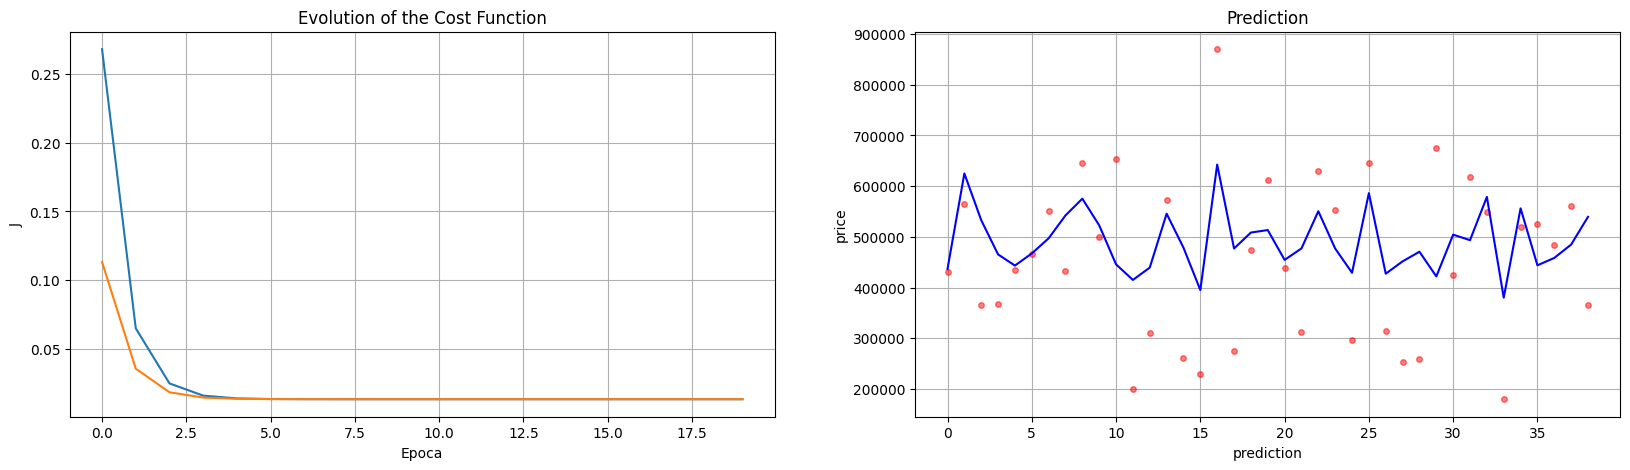

In [13]:
plt.figure(figsize=(20,5))

plt.subplot(1, 2, 1)
plt.plot(cost_train_list)
plt.plot(cost_val_list)
plt.title('Evolution of the Cost Function')
plt.ylabel('J')
plt.xlabel('Epoca')
plt.grid()


prediction = lin_reg_f_wb(X_test, w, b)
prediction = Y_scaler.inverse_transform(prediction) # 
price = Y_scaler.inverse_transform(Y_test)

step = 50
len_step = range(len(price))[0:-1: step] # vectorul care contine numarul corespondent epoci
price = price[0:-1: step].flatten()
prediction = prediction[0:-1: step].flatten()

plt.subplot(1, 2, 2)
plt.plot(price.astype(int), 'o', markersize=4, color='red', alpha=0.5)
plt.plot(prediction.astype(int), color='blue')
plt.title('Prediction')
plt.ylabel('price')
plt.xlabel('prediction')
#plt.ticklabel_format(style='plain', axis='y') # Dezactivezi notația științifică (scientific=False)
plt.grid()
plt.show()

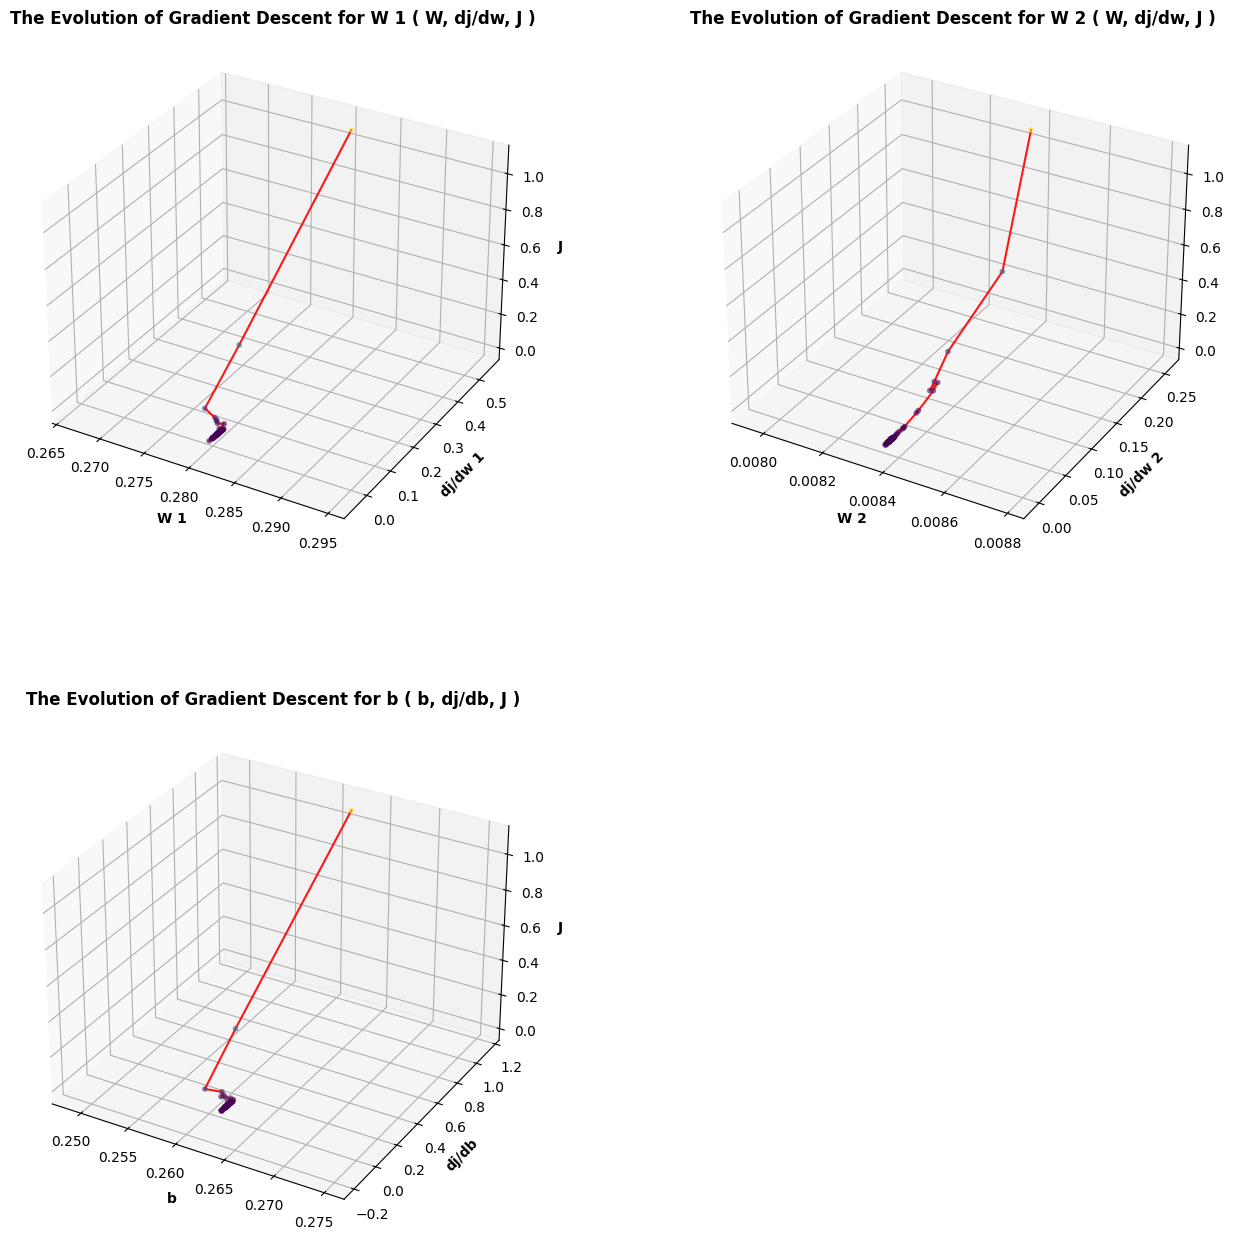

In [14]:
step = 50

all_cost = all_cost[::step]
w_list1 = list(w_list[0,:])[::step]
w_list2 = list(w_list[1,:])[::step]
dj_dw_list1 = list(dj_dw_list[0,:])[::step]
dj_dw_list2 = list(dj_dw_list[1,:])[::step]
b_list = b_list[::step]
dj_db_list = dj_db_list[::step]

all_cost = np.array(all_cost).flatten()
w_list1 = np.array(w_list1).flatten()
w_list2 = np.array(w_list2).flatten()
dj_dw_list1 = np.array(dj_dw_list1).flatten()
dj_dw_list2 = np.array(dj_dw_list2).flatten()
b_list = np.array(b_list).flatten()
dj_db_list = np.array(dj_db_list).flatten()



fig = plt.figure(figsize=(15, 15))

# Primul grafic 3D
ax1 = fig.add_subplot(2, 2, 1, projection='3d')
ax1.plot(w_list1, dj_dw_list1, all_cost, alpha=0.9, c='r')
ax1.scatter3D(w_list1, dj_dw_list1, all_cost, c=all_cost, cmap='viridis', s=10, alpha=0.5)
ax1.set_title('The Evolution of Gradient Descent for W 1 ( W, dj/dw, J )', fontweight='bold')
ax1.set_xlabel('W 1', fontweight='bold')
ax1.set_ylabel('dj/dw 1', fontweight='bold')
ax1.set_zlabel('J', fontweight='bold')

# Al doilea grafic 3D
ax2 = fig.add_subplot(2, 2, 2, projection='3d')
ax2.plot(w_list2, dj_dw_list2, all_cost, alpha=0.9, c='r')
ax2.scatter3D(w_list2, dj_dw_list2, all_cost, c=all_cost, cmap='viridis', s=10, alpha=0.5)
ax2.set_title('The Evolution of Gradient Descent for W 2 ( W, dj/dw, J )', fontweight='bold')
ax2.set_xlabel('W 2', fontweight='bold')
ax2.set_ylabel('dj/dw 2', fontweight='bold')
ax2.set_zlabel('J', fontweight='bold')

# Al treilea grafic 3D
ax3 = fig.add_subplot(2, 2, 3, projection='3d')
ax3.plot(b_list, dj_db_list, all_cost, alpha=0.9, c='r')
ax3.scatter3D(b_list, dj_db_list, all_cost, c=all_cost, cmap='viridis', s=10, alpha=0.5)
ax3.set_title('The Evolution of Gradient Descent for b ( b, dj/db, J )', fontweight='bold')
ax3.set_xlabel('b', fontweight='bold')
ax3.set_ylabel('dj/db', fontweight='bold')
ax3.set_zlabel('J', fontweight='bold')

plt.tight_layout(pad=10)
plt.show()


### Polynomial regression (polynomial degree = 2)

$$ f_\text{w,b}(x_1^{(i)}, x_2^{(i)}) = w_1 \cdot x_1^{(i)} + w_2 \cdot x_2^{(i)} + w_3 \cdot (x_1^{(i)})^2 + w_4 \cdot (x_2^{(i)})^2 + w_4 \cdot x_1^{(i)} \cdot x_2^{(i)} + b $$

### The matrix expression shows

$$
\mathbf{f_{w,b}(X_{poly})} = 
\underbrace{
\begin{bmatrix} 
x_1^{(1)} & x_2^{(1)} & (x_1^{(1)})^2 & (x_2^{(1)})^2 & (x_1^{(1)}x_2^{(1)}) \\ 
x_1^{(2)} & x_2^{(2)} & (x_1^{(2)})^2 & (x_2^{(2)})^2 & (x_1^{(2)}x_2^{(2)}) \\ 
\vdots & \vdots & \vdots & \vdots & \vdots \\ 
x_1^{(m)} & x_2^{(m)} & (x_1^{(m)})^2 & (x_2^{(m)})^2 & (x_1^{(m)}x_2^{(m)}) 
\end{bmatrix}}_{X_{poly}} \cdot 
\underbrace{
\begin{bmatrix} w_1 \\ w_2 \\ w_3 \\ w_4 \\ w_5 \end{bmatrix}}_{w} + b
$$

In [15]:
# Creaza un polinom de gradul 2 din caracteristicile de intrare
def expand_polynomial_degree2(x):
    poly = PolynomialFeatures(degree=2, include_bias=False)
    X_poly = poly.fit_transform(x)
    return X_poly
    

In [16]:
poly_x = expand_polynomial_degree2(x_norm)
print(poly_x.shape)

(9719, 5)


In [17]:
# Din setul de date extragem 60% pentru antrenament 
X_train, X_temp, Y_train, Y_temp = train_test_split(poly_x , y_norm, test_size=0.4, random_state=50)

# Datele temp se inpart in validare 20% si testare 20%
X_val, X_test, Y_val, Y_test = train_test_split( X_temp, Y_temp, test_size=0.5, random_state=5)

print('Shape value for data training, validation end test')
print(X_train.shape, Y_train.shape)
print(X_val.shape, Y_val.shape)
print(X_test.shape, Y_test.shape)

Shape value for data training, validation end test
(5831, 5) (5831, 1)
(1944, 5) (1944, 1)
(1944, 5) (1944, 1)


In [18]:
# Creaza pachetele pentru datele de validare si antrenament 
batch = 32
train_batches = batch_generator(X_train, Y_train, batch)
val_batches = batch_generator(X_train, Y_train, batch)

In [19]:
# create w
w = np.random.rand(X_train.shape[1], 1)# * 10 # I gave a higher value to the coefficient w to highlight the changes in the values of Gradient Descent
w = w.astype(np.float32)
# create bias
b = np.random.rand(1) 
b = np.float32(b)

print('w shape: ', w.shape)
print(w)
print('b value: ', b)

w shape:  (5, 1)
[[0.41156912]
 [0.07136041]
 [0.65214324]
 [0.6298343 ]
 [0.81817645]]
b value:  [0.7966753]


In [20]:
# Creaza pachetele pentru datele de validare si antrenament 
batch = 32
train_batches = batch_generator(X_train, Y_train, batch)
val_batches = batch_generator(X_train, Y_train, batch)

In [21]:
epocs = 20
alpha = 0.1
lambda_ = 1 #  0.001, 0.01, 0.1, 1, 10 

cost_train_list, cost_val_list, all_cost, dj_dw_list, w_list, dj_db_list, b_list, w, b = loop_training(epocs, alpha, lambda_, train_batches, val_batches, w, b)

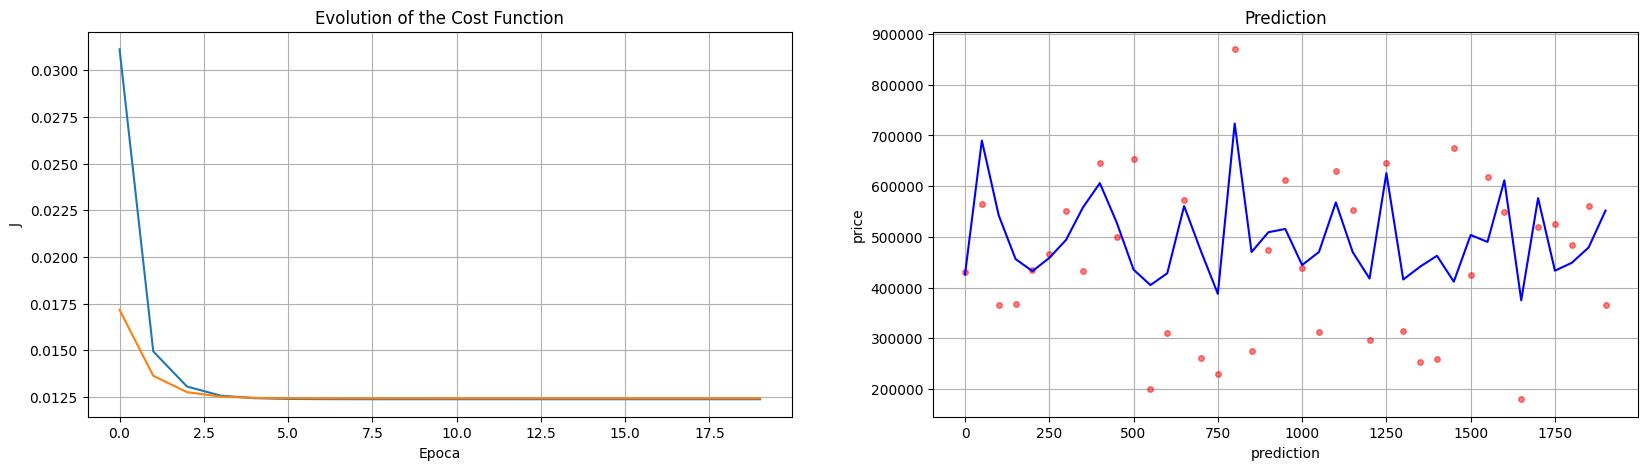

In [22]:
plt.figure(figsize=(20,5))

plt.subplot(1, 2, 1)
plt.plot(cost_train_list)
plt.plot(cost_val_list)
plt.title('Evolution of the Cost Function')
plt.ylabel('J')
plt.xlabel('Epoca')
plt.grid()


prediction = lin_reg_f_wb(X_test, w, b)
prediction = Y_scaler.inverse_transform(prediction)
price = Y_scaler.inverse_transform(Y_test)

step = 50
len_step = range(len(price))[0:-1: step] # vectorul care contine numarul corespondent epoci
price = price[0:-1: step].flatten()
prediction = prediction[0:-1: step].flatten()


plt.subplot(1, 2, 2)
plt.plot(len_step, price.astype(int), 'o', markersize=4, color='red', alpha=0.5)
plt.plot(len_step, prediction.astype(int), color='blue')
plt.title('Prediction')
plt.ylabel('price')
plt.xlabel('prediction')
plt.ticklabel_format(style='plain', axis='y') # Dezactivezi notația științifică (scientific=False)
plt.grid()
plt.show()

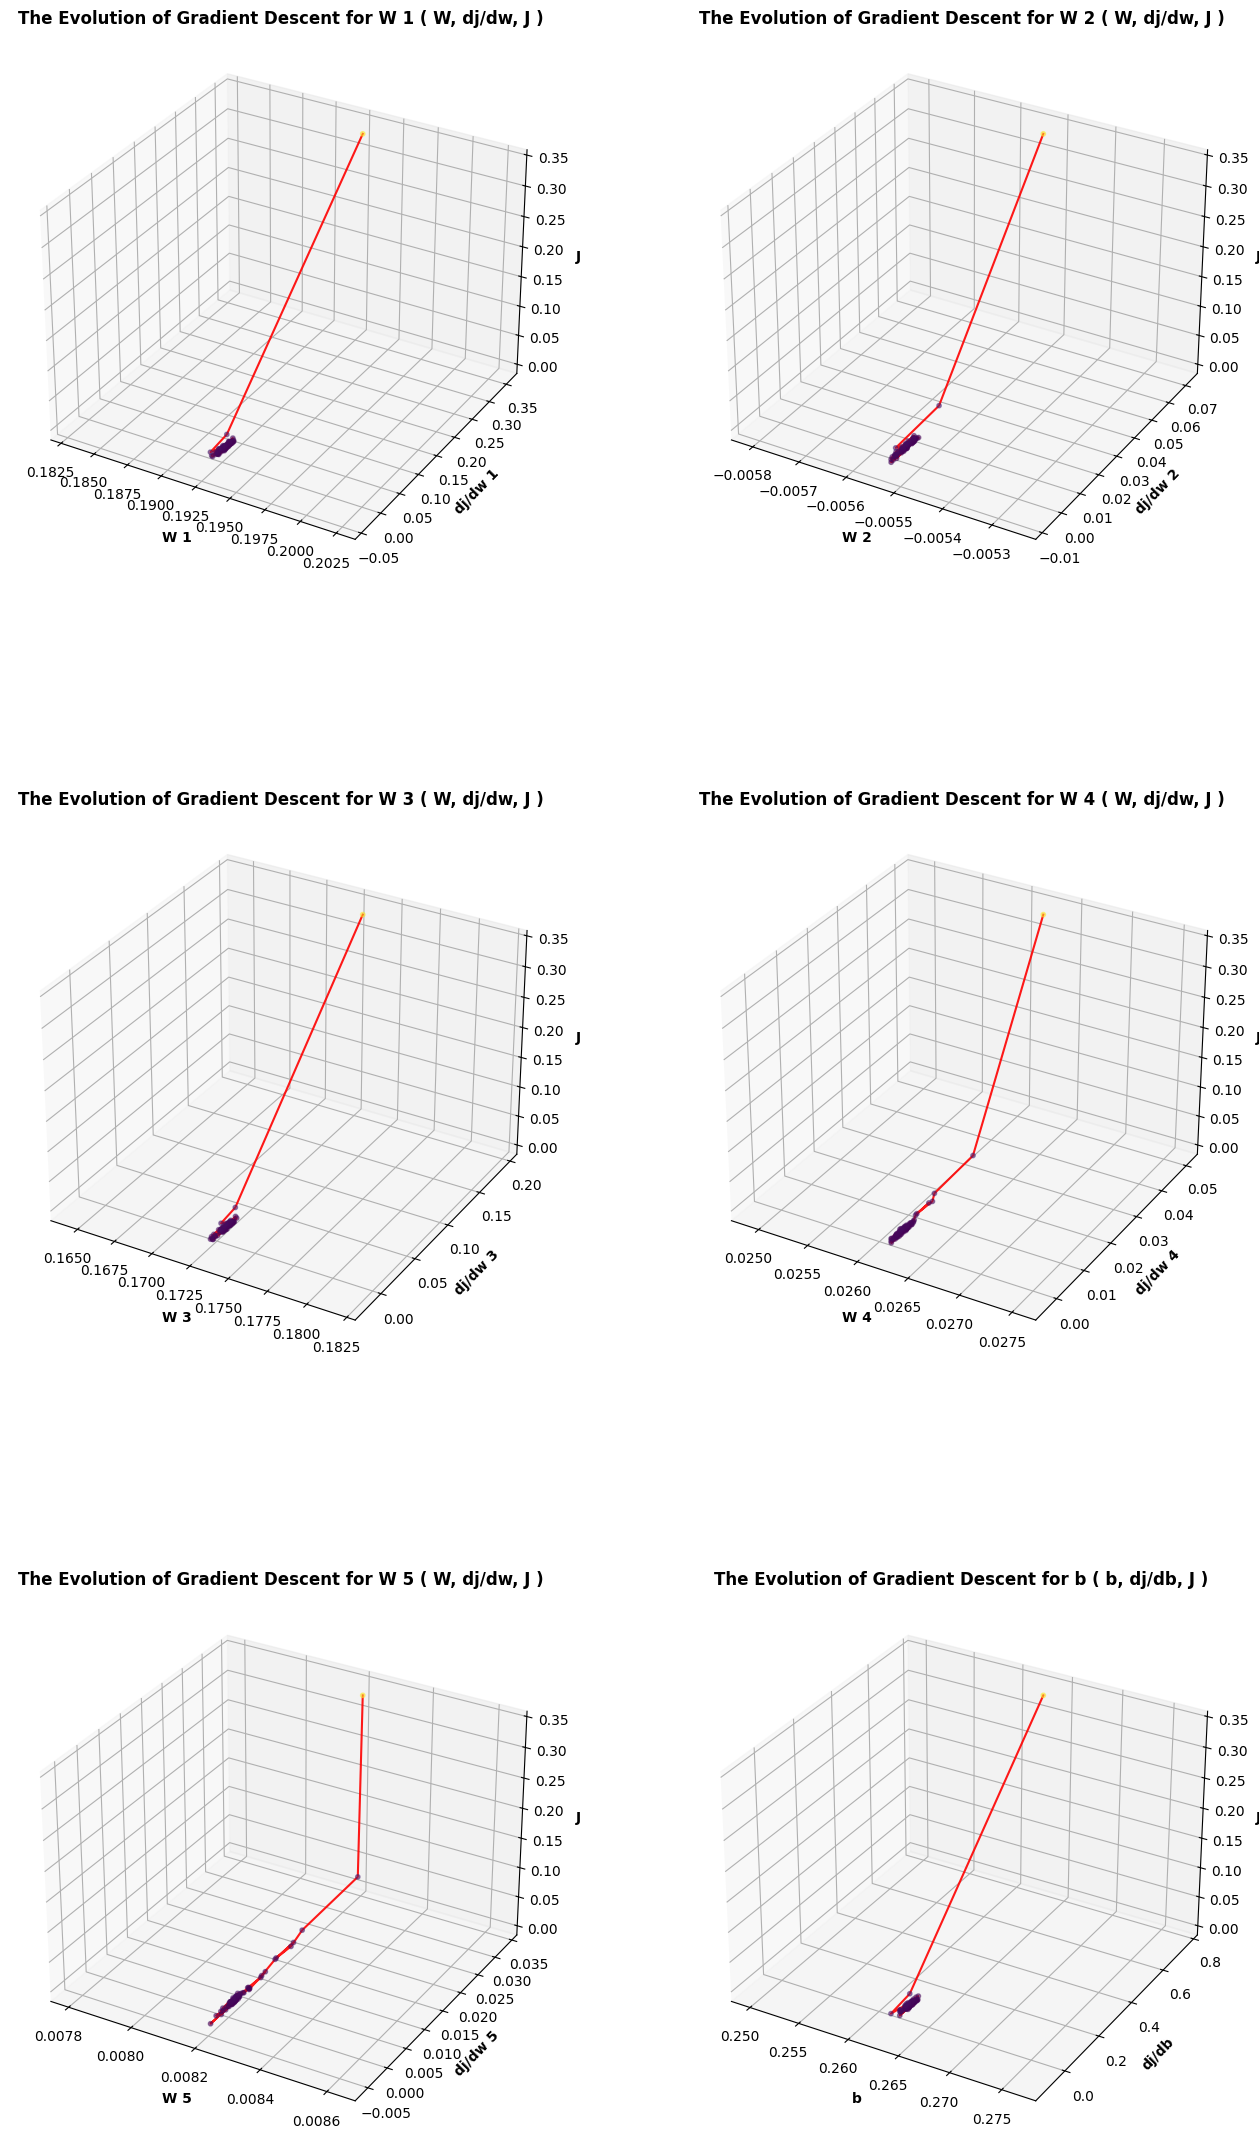

In [23]:
step = 50

all_cost = all_cost[::step]
w_list1 = list(w_list[0,:])[::step]
w_list2 = list(w_list[1,:])[::step]
w_list3 = list(w_list[2,:])[::step]
w_list4 = list(w_list[3,:])[::step]
w_list5 = list(w_list[4,:])[::step]
dj_dw_list1 = list(dj_dw_list[0,:])[::step]
dj_dw_list2 = list(dj_dw_list[1,:])[::step]
dj_dw_list3 = list(dj_dw_list[2,:])[::step]
dj_dw_list4 = list(dj_dw_list[3,:])[::step]
dj_dw_list5 = list(dj_dw_list[4,:])[::step]
b_list = b_list[::step]
dj_db_list = dj_db_list[::step]

all_cost = np.array(all_cost).flatten()
w_list1 = np.array(w_list1).flatten()
w_list2 = np.array(w_list2).flatten()
w_list3 = np.array(w_list3).flatten()
w_list4 = np.array(w_list4).flatten()
w_list5 = np.array(w_list5).flatten()
dj_dw_list1 = np.array(dj_dw_list1).flatten()
dj_dw_list2 = np.array(dj_dw_list2).flatten()
dj_dw_list3 = np.array(dj_dw_list3).flatten()
dj_dw_list4 = np.array(dj_dw_list4).flatten()
dj_dw_list5 = np.array(dj_dw_list5).flatten()
b_list = np.array(b_list).flatten()
dj_db_list = np.array(dj_db_list).flatten()



fig = plt.figure(figsize=(15, 25))


ax1 = fig.add_subplot(3, 2, 1, projection='3d')
ax1.plot(w_list1, dj_dw_list1, all_cost, alpha=0.9, c='r')
ax1.scatter3D(w_list1, dj_dw_list1, all_cost, c=all_cost, cmap='viridis', s=10, alpha=0.5)
ax1.set_title('The Evolution of Gradient Descent for W 1 ( W, dj/dw, J )', fontweight='bold')
ax1.set_xlabel('W 1', fontweight='bold')
ax1.set_ylabel('dj/dw 1', fontweight='bold')
ax1.set_zlabel('J', fontweight='bold')


ax2 = fig.add_subplot(3, 2, 2, projection='3d')
ax2.plot(w_list2, dj_dw_list2, all_cost, alpha=0.9, c='r')
ax2.scatter3D(w_list2, dj_dw_list2, all_cost, c=all_cost, cmap='viridis', s=10, alpha=0.5)
ax2.set_title('The Evolution of Gradient Descent for W 2 ( W, dj/dw, J )', fontweight='bold')
ax2.set_xlabel('W 2', fontweight='bold')
ax2.set_ylabel('dj/dw 2', fontweight='bold')
ax2.set_zlabel('J', fontweight='bold')


ax3 = fig.add_subplot(3, 2, 3, projection='3d')
ax3.plot(w_list3, dj_dw_list3, all_cost, alpha=0.9, c='r')
ax3.scatter3D(w_list3, dj_dw_list3, all_cost, c=all_cost, cmap='viridis', s=10, alpha=0.5)
ax3.set_title('The Evolution of Gradient Descent for W 3 ( W, dj/dw, J )', fontweight='bold')
ax3.set_xlabel('W 3', fontweight='bold')
ax3.set_ylabel('dj/dw 3', fontweight='bold')
ax3.set_zlabel('J', fontweight='bold')


ax4 = fig.add_subplot(3, 2, 4, projection='3d')
ax4.plot(w_list4, dj_dw_list4, all_cost, alpha=0.9, c='r')
ax4.scatter3D(w_list4, dj_dw_list4, all_cost, c=all_cost, cmap='viridis', s=10, alpha=0.5)
ax4.set_title('The Evolution of Gradient Descent for W 4 ( W, dj/dw, J )', fontweight='bold')
ax4.set_xlabel('W 4', fontweight='bold')
ax4.set_ylabel('dj/dw 4', fontweight='bold')
ax4.set_zlabel('J', fontweight='bold')


ax5 = fig.add_subplot(3, 2, 5, projection='3d')
ax5.plot(w_list5, dj_dw_list5, all_cost, alpha=0.9, c='r')
ax5.scatter3D(w_list5, dj_dw_list5, all_cost, c=all_cost, cmap='viridis', s=10, alpha=0.5)
ax5.set_title('The Evolution of Gradient Descent for W 5 ( W, dj/dw, J )', fontweight='bold')
ax5.set_xlabel('W 5', fontweight='bold')
ax5.set_ylabel('dj/dw 5', fontweight='bold')
ax5.set_zlabel('J', fontweight='bold')

# Al treilea grafic 3D
ax6 = fig.add_subplot(3, 2, 6, projection='3d')
ax6.plot(b_list, dj_db_list, all_cost, alpha=0.9, c='r')
ax6.scatter3D(b_list, dj_db_list, all_cost, c=all_cost, cmap='viridis', s=10, alpha=0.5)
ax6.set_title('The Evolution of Gradient Descent for b ( b, dj/db, J )', fontweight='bold')
ax6.set_xlabel('b', fontweight='bold')
ax6.set_ylabel('dj/db', fontweight='bold')
ax6.set_zlabel('J', fontweight='bold')

plt.tight_layout(pad=10)
plt.show()
